In [1]:
import numpy as np
import matplotlib.pyplot as plt

def do_interval(intervals, against = None):
    # compute overlap integral for a shift k
    
    I = sum((v-u)*a for u,v,a in intervals) 
    intervals = [(a, b, c/I) for a, b, c in intervals]

    for _, _, c in intervals: 
        if c > 1 : 
            return

    if (1 - intervals[0][2] < intervals[0][2]):
        intervals = [(a, b, 1-c) for a, b, c in intervals]
    
    I = sum((v-u)*a for u,v,a in intervals) 
    print("area = ", I)
    
    def overlap(k):
        # integration bounds where both x and x+k are in [0,2]
        x_start = max(0, -k)
        x_end = min(2, 2 - k)
        if x_end <= x_start:
            return 0.0  # no overlap possible

        total = 0.0
        for u1, v1, a1 in intervals:
            # restrict first interval to integration bounds
            u1_clip = max(u1, x_start)
            v1_clip = min(v1, x_end)
            if v1_clip <= u1_clip:
                continue
            for u2, v2, a2 in intervals:
                # shift second interval
                u2_shift, v2_shift = u2 - k, v2 - k
                # intersection length with clipped first interval
                inter = max(0, min(v1_clip, v2_shift) - max(u1_clip, u2_shift))
                total += a1 * a2 * inter
        return total

    # integral of f(x) over valid x for this k
    def I_k(k):
        x_start = max(0, -k)
        x_end = min(2, 2 - k)
        if x_end <= x_start:
            return 0.0
        return sum(a * max(0, min(v, x_end) - max(u, x_start)) for u, v, a in intervals)

    # function to maximize
    def F(k):
        return I_k(k) - overlap(k)

    # scan over k to find approximate maximum
    def best_ish(intervals, k_min=-2.0, k_max=2.0, num=200):
        ks = np.linspace(k_min, k_max, num)
        Fs = np.array([F(k) for k in ks])
        k_best = ks[np.argmax(Fs)]
        return k_best, Fs, ks

    k_best, Fs, ks = best_ish(intervals)

    print("Approx best k:", k_best)
    print("Max F(k):", np.max(Fs))
    print("Variance: ", np.var(Fs))

    # plot F(k)
    plt.figure(figsize=(8,4))
    plt.plot(ks, Fs, label="F(k)")
    plt.xlabel("k (shift)")
    plt.ylabel("Integral f(x)(1-f(x+k)) dx")
    plt.title("Maximizing Shift k for Step Function")
    plt.legend()
    plt.grid(True)
    plt.show()

    # plot the step function f(x)
    plt.figure(figsize=(8,2))
    for u, v, a in intervals:
        plt.hlines(a, u, v, colors='b', linewidth=6, alpha=0.5)
    if (against != None): 
        for u, v, a in against:
            plt.hlines(a, u, v, colors='r', linewidth=6, alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Step Function f(x)")
    plt.ylim(0,1.2)
    plt.grid(True)
    plt.show()

area =  0.9999999999999999
Approx best k: 0.1507537688442211
Max F(k): 0.3809268534330872
Variance:  0.020868808968665428


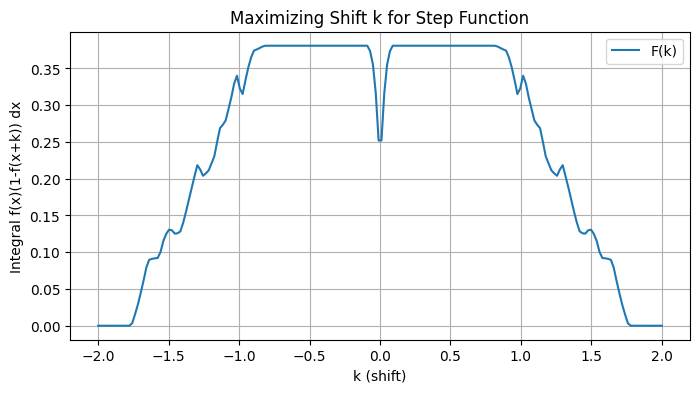

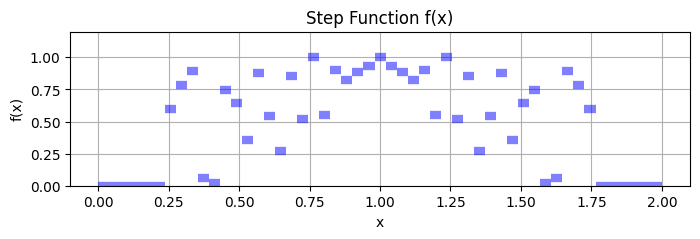

In [2]:
# 51-step function, heights for x in [0,1]
heights = [
    0,
    0.0002938681556273,
    0.5952882223921177,
    0.7844530825484313,
    0.8950034338013842,
    0.0597964076006748,
    0.0189602838469592,
    0.7420501628172980,
    0.6444559588500921,
    0.3549040817844764,
    0.8762442385073478,
    0.5437907313675501,
    0.2679640048997296,
    0.8518954615823791,
    0.5211171156914872,
    1,
    0.5506146790047043,
    0.9007715390796991,
    0.8229000691941086,
    0.8879541710440111,
    0.9315424878319221,
    1
]

positions = [
    0/51, 10/51, 12/51, 14/51, 16/51, 18/51, 20/51, 22/51, 24/51, 26/51,
    28/51, 30/51, 32/51, 34/51, 36/51, 38/51, 40/51, 42/51, 44/51, 46/51,
    48/51, 50/51, 1.0
]

intervals = []
for i in range(len(positions)-1):
    intervals.append((positions[i], positions[i+1], heights[i]))

intervals_mirror = [(2-end, 2-start, h) for start, end, h in reversed(intervals)]
intervals += intervals_mirror

h51 = intervals

do_interval(intervals)

In [ ]:
intervals = [(0.0, 0.5, 0), (0.5, 1.0, 1)]
intervals_mirror = [(2-end, 2-start, h) for start, end, h in reversed(intervals)]
intervals += intervals_mirror
do_interval(intervals)

In [5]:
def cpp_to_py_nomirr (ls) : 
    size = len(ls) / 2
    return [(i/size, (i+1)/size, x) for i, x in enumerate(ls)]

def cpp_to_py (ls) : 
    size = len(ls)
    intervals = [(i/size, (i+1)/size, x) for i, x in enumerate(ls)]
    intervals_mirror = [(2-end, 2-start, h) for start, end, h in reversed(intervals)]
    intervals += intervals_mirror
    return intervals

def cpp_to_py_smallpeak (ls) : 
    ls_mirror = [h for h in reversed(ls)]
    ls += ls_mirror[1:]
    return cpp_to_py_nomirr (ls)

area =  0.9999999999999999
Approx best k: -0.25125628140703515
Max F(k): 0.3851337232529073
Variance:  0.020455144477690493


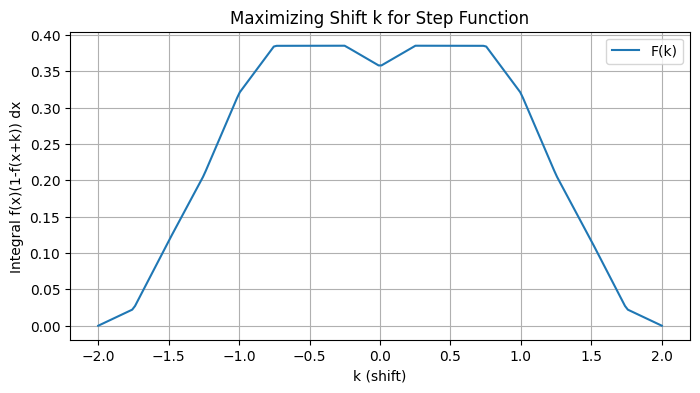

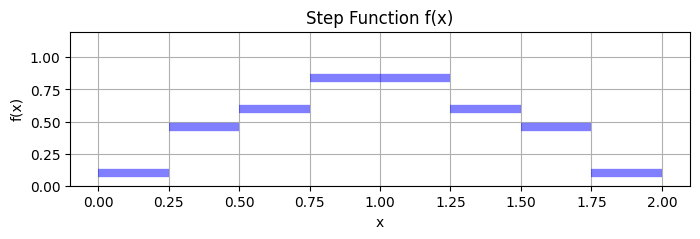

In [6]:
do_interval(cpp_to_py([0.101929, 0.457442, 0.60021, 0.84042]))

area =  1.0
Approx best k: -0.31155778894472363
Max F(k): 0.38342240742866385
Variance:  0.020499415351527578


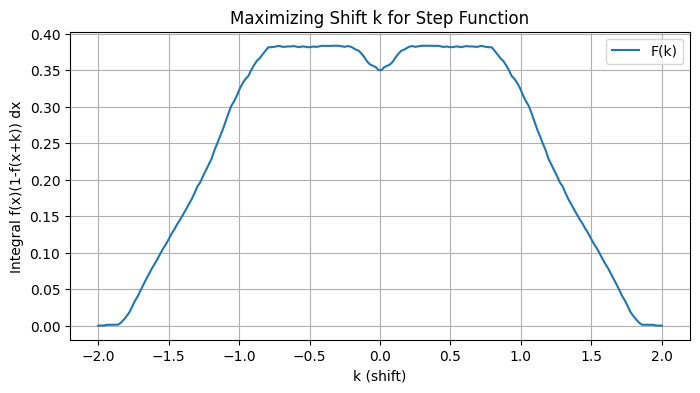

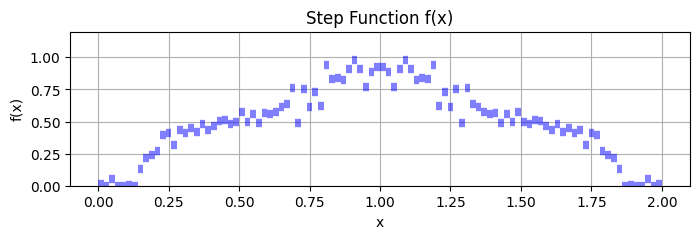

In [7]:
do_interval(cpp_to_py([0.0122713, 0, 0.0490706, 0, 0, 0.00552512, 0, 0.126926, 0.21467, 0.240242, 0.272234, 0.394852, 0.414537, 0.315118, 0.436151, 0.413512, 0.451885, 0.419339, 0.477182, 0.432286, 0.464689, 0.507738, 0.514468, 0.477504, 0.49734, 0.573416, 0.492791, 0.560253, 0.489414, 0.569852, 0.560789, 0.572181, 0.615895, 0.636583, 0.76161, 0.486248, 0.753414, 0.616913, 0.731792, 0.62177, 0.941509, 0.830022, 0.842182, 0.824703, 0.910346, 0.981685, 0.908308, 0.77251, 0.887045, 0.921229,]))

area =  1.0
Approx best k: -0.4120603015075377
Max F(k): 0.3854075466905217
Variance:  0.02036246210706941


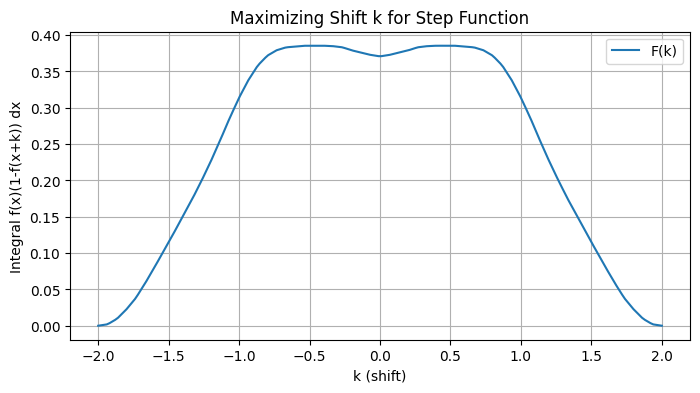

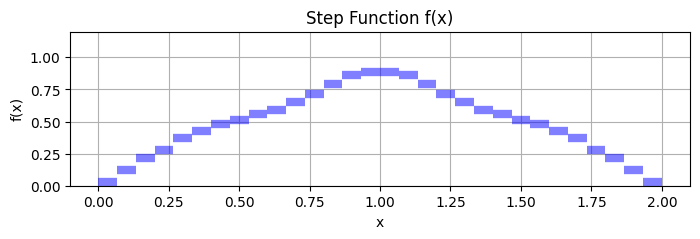

In [8]:
do_interval(cpp_to_py([0.0304242, 0.120264, 0.214313, 0.274689, 0.372955, 0.430207, 0.478631, 0.511812, 0.561031, 0.590697, 0.654051, 0.716756, 0.793717, 0.863987, 0.886464]))

In [ ]:
do_interval(cpp_to_py_nomirr([
    0.997192, 0.76334, 0.510637, 0.558936, 0.372201, 0.35672, 0.120972, 0.175103, 0.0574629, 0.38427, 0.373124, 0.559309, 0.510738, 0.766878, 0.993117
]))

A tent makes sense at first but when x is almost 1, the highest (peak of tent) align with the lowest (tail) which means the 
convoluted result will be high sum (peaks * 1 - tails). So

area =  1.0
Approx best k: -0.793969849246231
Max F(k): 0.3815315482351084
Variance:  0.020794558918016383


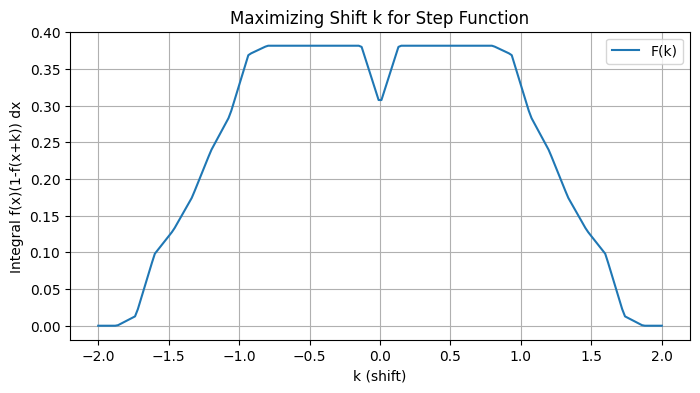

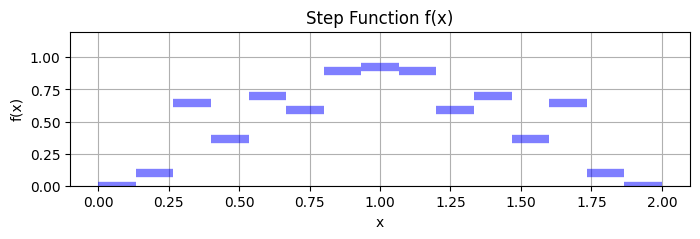

In [13]:
# Haugland 15
h15 = cpp_to_py([ 0.0, 0.0, 0.09938602, 0.09938602, 0.64299877, 0.64299877, 0.36104582, 0.36104582, 0.69536426, 0.69536426, 0.59241335, 0.59241335, 0.89573331, 0.89573331, 0.92611694 ])
do_interval(h15)

area =  0.9999999999999999
Approx best k: -0.5326633165829147
Max F(k): 0.3831228280513876
Variance:  0.02075391679212032


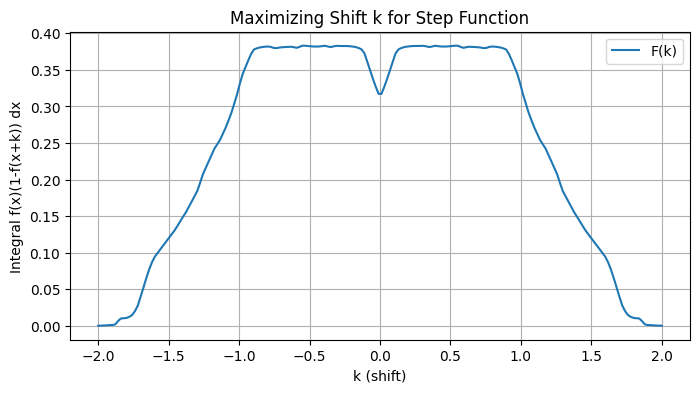

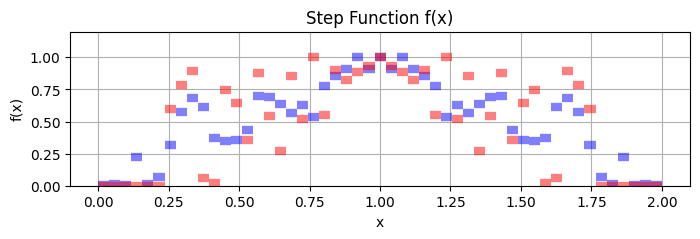

In [14]:
# The same genetic search optimized for N=8 in 5 minutes
do_interval(cpp_to_py_smallpeak([
    1.0755, 1.06616, 1.07425, 0.837325, 1.06632, 1.0067, 0.73571, 0.463978, 0.34187, 0.415953, 0.676507, 0.703353, 0.698703, 0.612886, 0.328046, 0.332808, 0.3952, 0.468745, 0.402982, 0.502299, 0.244036, 0.154008, 0.0973924, 0, 0.101749, 0
]), against=h51)
# Getting closer to the shape of haugland's -> optimize speed to /5 that and run with more searching power

area =  1.0
Approx best k: 0.4321608040201004
Max F(k): 0.3825724473951825
Variance:  0.020797690908867107


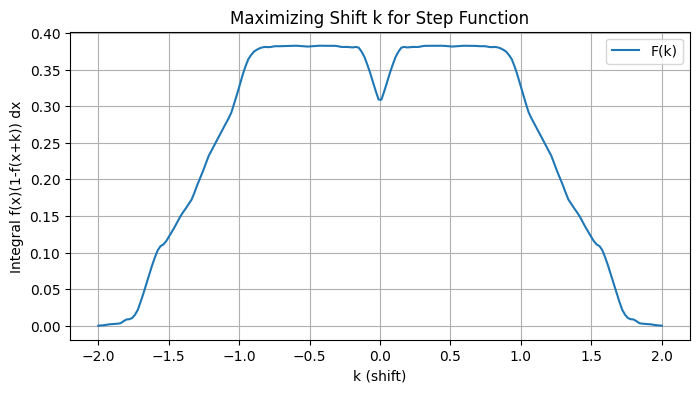

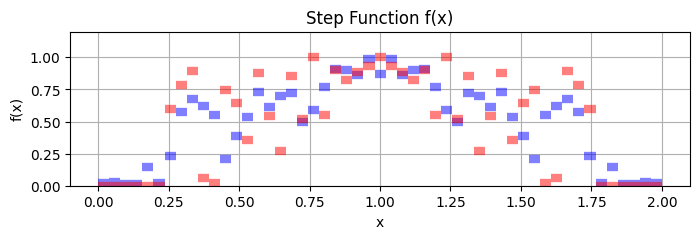

In [11]:
do_interval(cpp_to_py_smallpeak([
   1.29242, 1.27374, 1.29851, 1.29522, 1.12856, 1.28641, 1.01353, 0.557183, 0.426819, 0.494752, 0.587932, 1.04641, 0.805685, 0.607166, 0.357141, 0.513457, 0.393914, 0.364553, 0.666885, 0.535343, 0.306003, 0.11497, 0.125294, 0.183541, 0.0182484, 0.174265
]), against=h51)

Concern is running with higher N does not give better result. This is bad. Another idea is to start with N=8 find optimal shape, that do N=24 from that N=8, and then do N=72 and so on.

But no, finer resolution did not improve existing one. Consistently. This is weird. It's like each N has it's own optimal piecewise function. This is bad cause it's impossible to search high N with lower resolution first. 

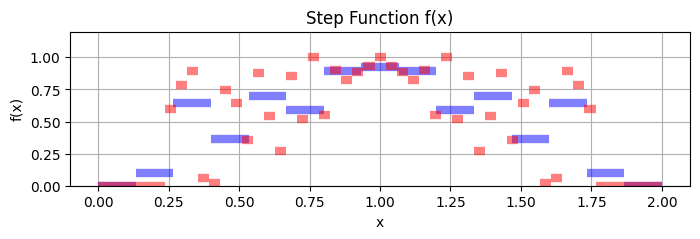

In [15]:
# HAUGLAND'S RESULT
plt.figure(figsize=(8,2))
for u, v, a in h15:
    plt.hlines(a, u, v, colors='b', linewidth=6, alpha=0.5)
for u, v, a in h51:
    plt.hlines(a, u, v, colors='r', linewidth=6, alpha=0.5)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Step Function f(x)")
plt.ylim(0,1.2)
plt.grid(True)
plt.show()

area =  1.0
Approx best k: -0.31155778894472363
Max F(k): 0.38266078960405536
Variance:  0.020758279946801492


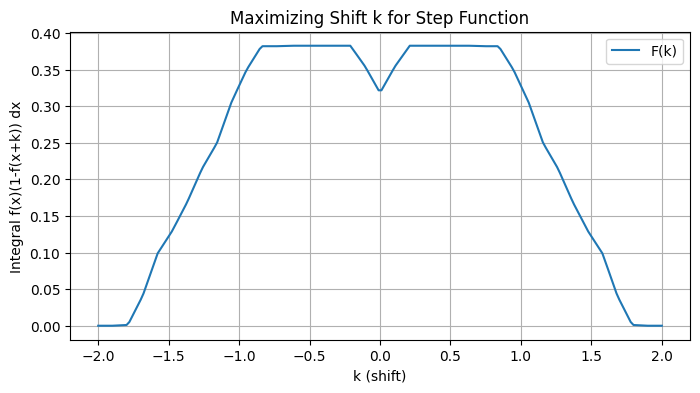

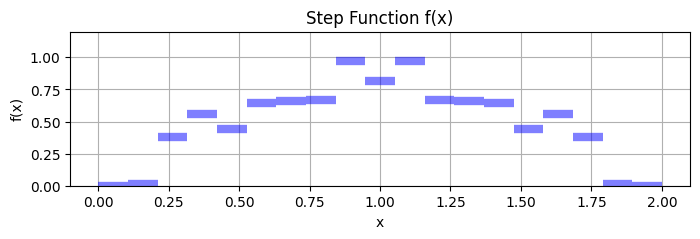

area =  1.0
Approx best k: -0.3718592964824121
Max F(k): 0.3816153797313734
Variance:  0.021190618207011912


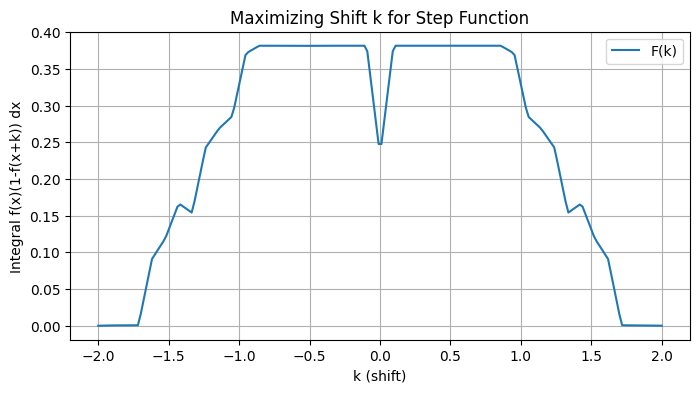

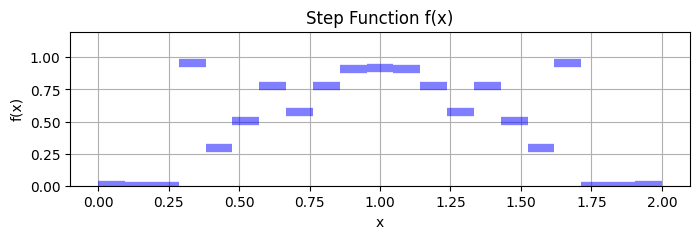

area =  0.9999999999999999
Approx best k: -0.4321608040201004
Max F(k): 0.38216762985374064
Variance:  0.02088704973624754


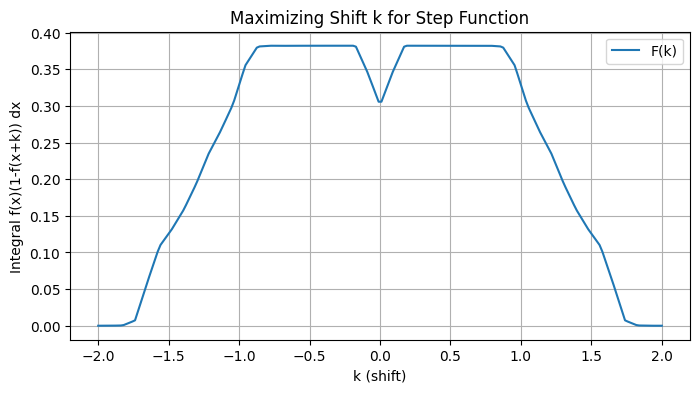

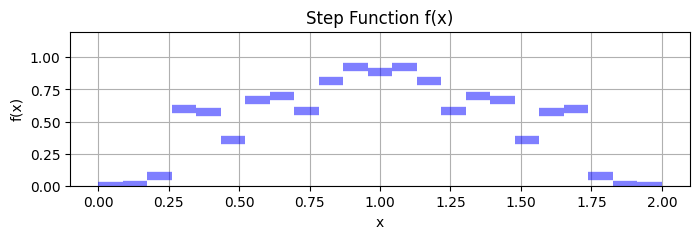

area =  1.0
Approx best k: -0.3919597989949748
Max F(k): 0.38199019757221275
Variance:  0.02087163914919829


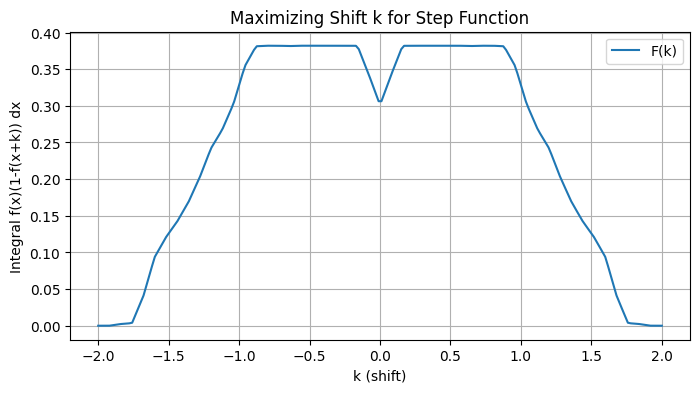

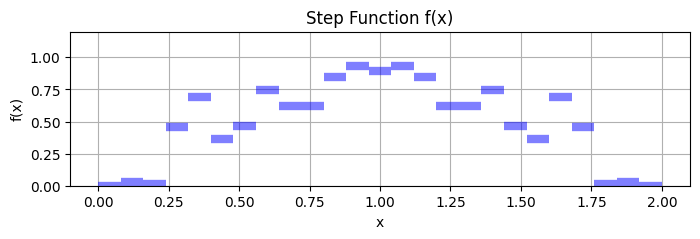

area =  1.0
Approx best k: -0.1507537688442211
Max F(k): 0.38182254932691295
Variance:  0.02087522670747135


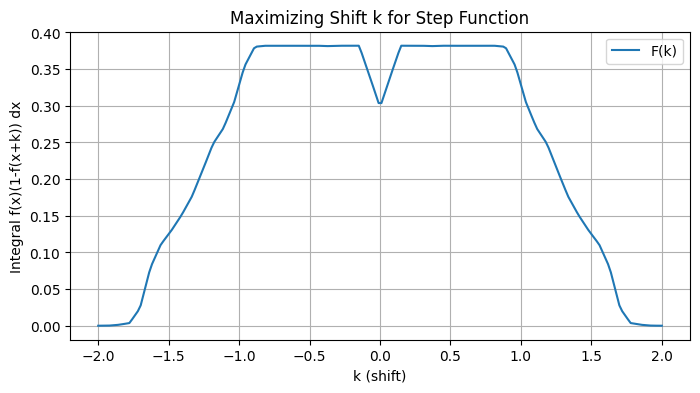

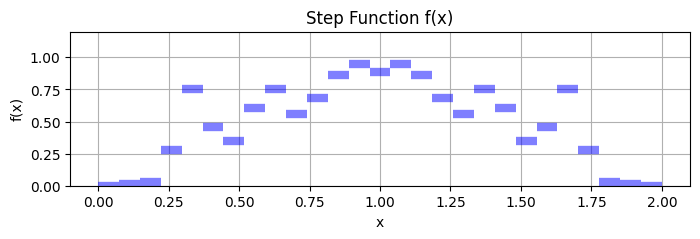

In [19]:
# N=10 -> 19 pieces
do_interval(cpp_to_py_smallpeak([
    0, 0.0136226, 0.503817, 0.738821, 0.591016, 0.858396, 0.881971, 0.888462, 1.29694, 1.08615,
]))

# N=11 -> 21 pieces
do_interval(cpp_to_py_smallpeak([
   0.00577582, 0, 0.00183534, 1.12593, 0.342038, 0.595856, 0.917379, 0.672977, 0.912101, 1.07313, 1.07656
]))

# N=12 -> 23 pieces
do_interval(cpp_to_py_smallpeak([
   0, 0.004864, 0.0888563, 0.682834, 0.661967, 0.403809, 0.764108, 0.803178, 0.666218, 0.936924, 1.06244, 1.01683
]))

# N=13 -> 25 pieces
do_interval(cpp_to_py_smallpeak([
   1.14176, 1.11006, 1.12346, 0.619989, 0.352705, 0.723589, 0.608555, 0.28687, 0.431876, 0.434676, 0.175481, 0.0727402, 0.116768,
]))

# N=14 -> 27 pieces
do_interval(cpp_to_py_smallpeak([
  1.13833, 1.12166, 1.10324, 0.827007, 0.27905, 0.616062, 0.740687, 0.445351, 0.278411, 0.505459, 0.364114, 0.154411, 0.0583195, 0.126529
]))